## How to use this notebook

- **Single-run cells**: The first few code cells run one set of simulations for the three AI policies and are used by any Gantt or single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` run many simulations per policy and feed the aggregate statistics and box/whisker plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block to update the aggregate visualizations.

In [1]:
from run_simulation import run_simulation, print_statistics, run_multiple_simulations
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
)
import matplotlib.pyplot as plt
import numpy as np

# Common parameters for both analyses
NUM_PERMITS = 6410
RANDOM_SEED = 36
INTER_ARRIVAL_TIME = 0.0  # run permits back-to-back

In [2]:
# Run all three simulations
print(f"Running standard simulation with {NUM_PERMITS} permits...")
sim_standard = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
    ai_review="none",
)

print(f"\nRunning initial AI check simulation with {NUM_PERMITS} permits...")
sim_initial = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
    ai_review="initial_check",
)

print(f"\nRunning full AI review simulation with {NUM_PERMITS} permits...")
sim_full = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
    ai_review="full_review",
)

Running standard simulation with 6410 permits...

Running initial AI check simulation with 6410 permits...

Running full AI review simulation with 6410 permits...


In [3]:
# Print statistics for each process
print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("=== AI INITIAL CHECK PROCESS ===")
stats_initial = sim_initial.get_statistics()
print_statistics(stats_initial)

print("\n=== AI FULL REVIEW PROCESS ===")
stats_full = sim_full.get_statistics()
print_statistics(stats_full)

=== STANDARD PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4632 (72.26%)
  CUSTOM_NON_LIKE               : 1158 (18.07%)
  PRE_APPROVED_LIKE             :  110 ( 1.72%)
  PRE_APPROVED_NON_LIKE         :   29 ( 0.45%)
  SELF_CERT_LIKE                :  391 ( 6.10%)
  SELF_CERT_NON_LIKE            :   90 ( 1.40%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     326.10 days
  Median:   310.98 days
  Std Dev:  121.02 days
  Min:       88.27 days
  Max:     1397.49 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT
-

In [4]:
# Run multiple simulations for each AI scenario to see aggregate behavior
n_runs = 100

scenario_params_list = [
    {"name": "Standard", "sequential": "standard", "ai_review": "none"},
    {"name": "Initial AI Check", "sequential": "standard", "ai_review": "initial_check"},
    {"name": "Full AI Review", "sequential": "standard", "ai_review": "full_review"},
]

multi_results = run_multiple_simulations(
    n_runs=n_runs,
    num_permits=NUM_PERMITS,
    simulation_duration=None,
    base_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    scenario_params_list=scenario_params_list,
    collect_permits=True,
)

all_standard_permits: list = []
all_initial_permits: list = []
all_full_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Standard":
        all_standard_permits.extend(permits)
    elif scenario == "Initial AI Check":
        all_initial_permits.extend(permits)
    elif scenario == "Full AI Review":
        all_full_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


print(f"Ran {n_runs} runs per scenario (AI policies). Aggregate total-time stats:")
_print_summary("Standard", all_standard_permits)
_print_summary("Initial AI Check", all_initial_permits)
_print_summary("Full AI Review", all_full_permits)

Ran 100 runs per scenario (AI policies). Aggregate total-time stats:
Standard: n=641000, mean=325.34, median=309.84
Initial AI Check: n=641000, mean=320.40, median=304.28
Full AI Review: n=641000, mean=316.13, median=301.48


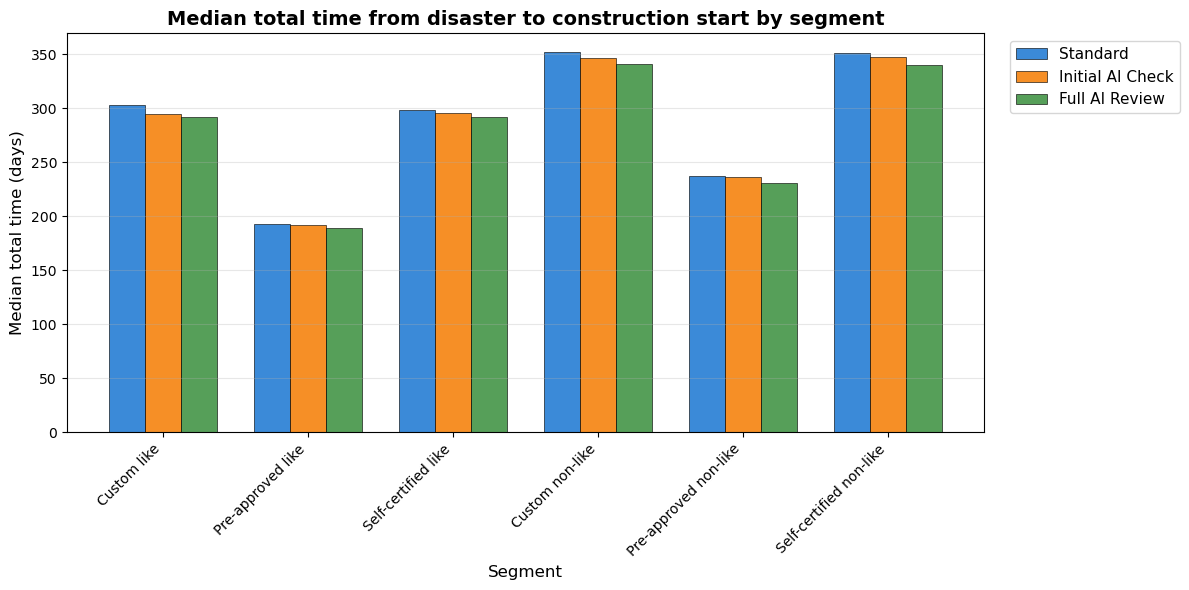

In [5]:
# Compare median total time (disaster to construction) by segment
# Use aggregated permits across many runs for each scenario
permits_by_process = {
    "Standard": all_standard_permits,
    "Initial AI Check": all_initial_permits,
    "Full AI Review": all_full_permits,
}
fig, ax = plot_median_total_time_by_process(permits_by_process)
if fig is not None:
    plt.show()